# 🖊️ MNIST Digit Classification

This notebook demonstrates digit classification using the MNIST dataset, following the workflow from Chapter 3 of "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow".



## 📦 Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

We use fetch_openml from scikit-learn to load the data

In [4]:
from sklearn.datasets import fetch_openml

In [14]:
mnist = fetch_openml('mnist_784', as_frame=False)


In [15]:
X,y = mnist.data, mnist.target
X.shape
y.shape

(70000,)

In [16]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [17]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

## 🖼️ Visualizing a Digit

The following function helps visualize a single MNIST digit:


In [ ]:
import matplotlib.pyplot as plt
def plot_digit(image_data):
    image = image_data.reshape(28, 28) # Reshape the 1D array to 2D (28x28)
    plt.imshow(image, cmap="binary") # Display the image in black and white color map
    plt.axis("off") # Hide the axes for better visualization

some_digit = X[0]
plot_digit(some_digit)
plt.show() # Display the plot

In [18]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## 🏷️ Training a Binary Classifier with SGDClassifier

We will train a binary classifier to identify a specific digit (e.g., "5") using the **SGDClassifier** from scikit-learn.

### What is SGDClassifier?

- **SGDClassifier** stands for **Stochastic Gradient Descent Classifier**.
- It is a linear classifier (e.g., logistic regression, linear SVM) trained using stochastic gradient descent.
- **Stochastic Gradient Descent (SGD)** updates the model weights using one training sample at a time, making it efficient for large datasets.
- It supports different loss functions (e.g., hinge for SVM, log for logistic regression).

### Example: Train a Classifier to Detect "5"

In [19]:
from sklearn.linear_model import SGDClassifier

# Create binary target: True for "5", False for other digits
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

# Initialize the SGDClassifier
sgd_clf = SGDClassifier(random_state=42)

# Train the classifier
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [21]:
some_digit = X[0]
sgd_clf.predict([some_digit])

array([ True])

## 📊 Performance Measures: Accuracy and Cross-Validation

After training a classifier, it's important to evaluate how well it performs. The book discusses several performance measures, including **accuracy** and **cross-validation**.

### Accuracy

- **Accuracy** is the proportion of correct predictions made by the classifier.
- For binary classification, it is calculated as:
  \[
  \text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}
  \]
- Accuracy is a simple and intuitive metric, but it may not be reliable for imbalanced datasets.

### Cross-Validation

- **Cross-validation** is a technique to assess the generalization performance of a model.
- The most common method is **k-fold cross-validation**:
  - The data is split into *k* subsets (folds).
  - The model is trained on *k-1* folds and tested on the remaining fold.
  - This process is repeated *k* times, each time with a different fold as the test set.
  - The average score across all folds gives a more robust estimate of model performance.


In [22]:
from sklearn.model_selection import cross_val_score
cross_val_score = cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print("Cross-validation accuracy scores:", cross_val_score)
print("Mean accuracy:", cross_val_score.mean())

Cross-validation accuracy scores: [0.95035 0.96035 0.9604 ]
Mean accuracy: 0.9570333333333334


## 🧑‍🎓 Baseline Model: DummyClassifier

To evaluate our classifier's true performance, we use a **DummyClassifier** as a baseline.  
DummyClassifier makes predictions using simple rules, such as always predicting the most frequent class. This helps us understand if our real model is actually learning useful patterns or just guessing.

### Why use DummyClassifier?

- It provides a baseline accuracy for comparison.
- If our real classifier does not outperform DummyClassifier, it means it is not learning anything useful.

### Example: DummyClassifier on MNIST "5" Detector

In [23]:
from sklearn.dummy import DummyClassifier

# Initialize DummyClassifier (default strategy is "prior", which predicts the most frequent class)
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)

# Predict on the training set and check if any prediction is True (i.e., predicts "5")
print(any(dummy_clf.predict(X_train)))


False


## 📉 Understanding the Confusion Matrix

After evaluating our classifier's accuracy and comparing it to the DummyClassifier, we use a **confusion matrix** to get a deeper understanding of our model's predictions.

### What is a Confusion Matrix?

A confusion matrix is a table that summarizes the performance of a classification algorithm.  
For binary classification (like detecting "5" vs. not "5"), it shows:

- **True Positives (TP):** Correctly predicted "5"s
- **True Negatives (TN):** Correctly predicted not "5"s
- **False Positives (FP):** Predicted "5" when it's not "5"
- **False Negatives (FN):** Predicted not "5" when it is "5"

### Why Use a Confusion Matrix Here?

- **Accuracy alone can be misleading,** especially with imbalanced data (few "5"s, many not "5"s).
- The confusion matrix helps us see **how many "5"s are missed** (FN) and **how many non-"5"s are wrongly predicted as "5"** (FP).
- It provides more detail than just the overall accuracy, showing the strengths and weaknesses of our classifier.

### Example from the Notebook

In [26]:
from sklearn.model_selection import cross_val_score

# guessing model accuracy
dummy_scores = cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print("Cross-validation accuracy scores:", dummy_scores)

Cross-validation accuracy scores: [0.90965 0.90965 0.90965]


In [28]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [29]:
from sklearn.metrics import confusion_matrix
confusion_mtx = confusion_matrix(y_train_5, y_train_pred)
print("Confusion Matrix:\n", confusion_mtx)

Confusion Matrix:
 [[53892   687]
 [ 1891  3530]]


## 🎯 Precision/Recall Trade-Off and Decision Thresholds

After analyzing the confusion matrix, we want to understand how well our classifier balances **precision** (how many predicted "5"s are actually "5") and **recall** (how many actual "5"s are detected).

### Why Precision/Recall Trade-Off?

- **Precision**: Of all images predicted as "5", how many are truly "5"?
- **Recall**: Of all actual "5"s, how many did we correctly identify?
- Often, increasing one decreases the other. The right balance depends on your application.

### Using `decision_function` and Precision-Recall Curve

- The classifier's `decision_function` gives a score for each instance, not just a binary prediction.
- By varying the **decision threshold**, we can control the trade-off between precision and recall.
- Plotting a **precision-recall curve** helps visualize this trade-off.


In [30]:
some_digit = X[0]
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [31]:
thresold = 0
y_some_digit_pred = (y_scores > thresold)
y_some_digit_pred

array([ True])

In [32]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [33]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")


In [34]:
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

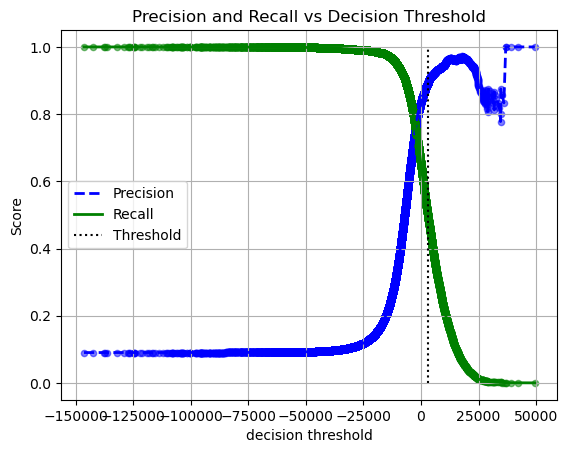

In [35]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted" , label="Threshold")

#beautify the plot
plt.grid(True)
plt.legend(loc="best")
plt.xlabel("decision threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold")

# Add Circles at some points for emphasis
plt.scatter(thresholds, precisions[:-1], color="blue", s=20, alpha=0.5)
plt.scatter(thresholds, recalls[:-1], color="green", s=20, alpha=0.5)
plt.show()


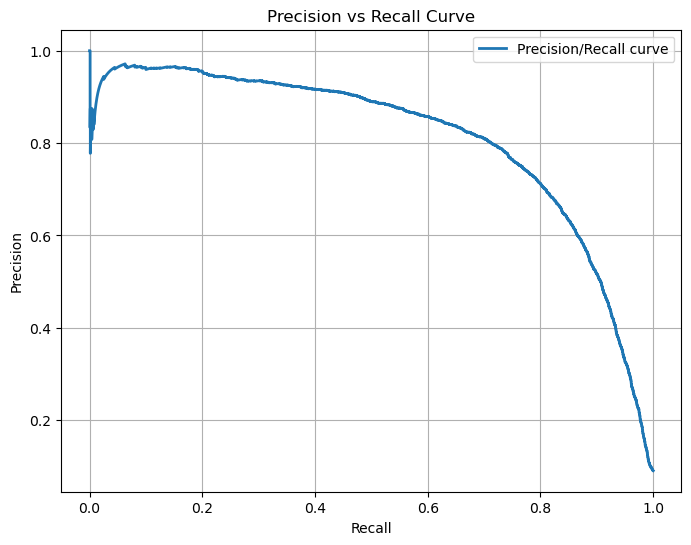

In [38]:
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# Add labels and title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Curve")

# Add grid and legend
plt.grid(True)
plt.legend(loc="best")



plt.show()

## 🏹 Using `argmax` to Find the Best Precision or Recall

Sometimes, you want to find the point on the precision-recall curve where precision or recall is maximized.  
This is where the `argmax` function from NumPy is useful.

### What is `argmax`?

- `np.argmax(array)` returns the **index of the maximum value** in the array.
- You can use this index to find the corresponding recall, precision, or threshold.

### Example: Find the Maximum Precision Point

In [39]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_90_precision = thresholds[idx_for_90_precision]
print("Threshold for 90% precision:", threshold_90_precision)

Threshold for 90% precision: 3370.0194991441817


In [40]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [42]:
from sklearn.metrics import precision_score
precision_score(y_train_5, y_train_pred_90)


0.9000345901072293

In [43]:
from sklearn.metrics import recall_score
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision


0.4799852425751706

## 📈 ROC Curve for SGDClassifier

The **ROC curve** (Receiver Operating Characteristic curve) helps visualize the trade-off between the true positive rate (recall) and the false positive rate for different decision thresholds.

Here’s how you can plot the ROC curve and calculate the ROC AUC score for your SGDClassifier:


In [44]:
from sklearn.metrics import roc_curve
fpr, tpr, roc_thresholds = roc_curve(y_train_5, y_scores)

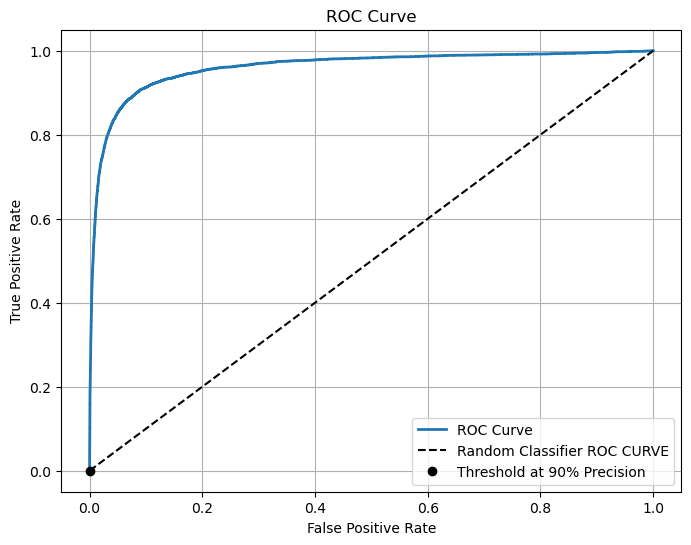

In [45]:
idx_for_threshold_at_90 = (thresholds <= threshold_90_precision).argmax()
tpr_90 , fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier ROC CURVE")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold at 90% Precision")

# Add labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")  
# Add grid and legend
plt.grid(True)
plt.legend(loc="best")
plt.show()

In [47]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_train_5, y_scores)
roc_auc

np.float64(0.9604938554008616)

## 🌲 RandomForestClassifier: Precision-Recall Curve and F1 Score Comparison

Let's train a `RandomForestClassifier` on the same MNIST "5" detection task and compare its precision-recall curve and F1 score to those of the `SGDClassifier`.




In [48]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.98, 0.02]])

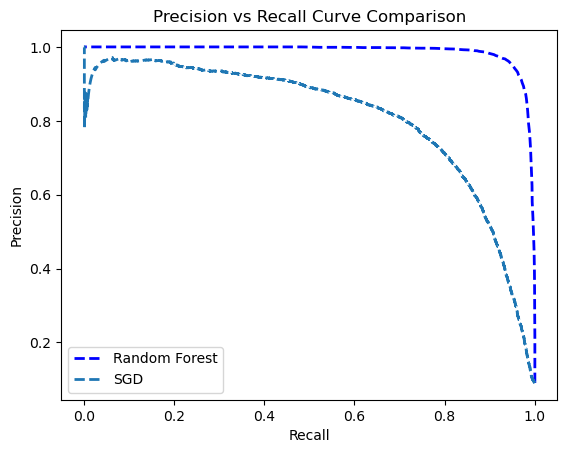

In [49]:
y_scores_forest = y_probas_forest[:, 1]  # Probability for class "5"
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

plt.plot(recalls_forest, precisions_forest, "b--", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Curve Comparison")
plt.legend(loc="best")
plt.show()

In [50]:
from sklearn.metrics import f1_score
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5
f1_score(y_train_5, y_train_pred_forest)


0.9270445185330457

In [51]:
roc_auc_forest = roc_auc_score(y_train_5, y_scores_forest)
roc_auc_forest

np.float64(0.9983296721818179)